# TP2 — ISAC distribué : perception collective et diffusion sélective sous contraintes  

### Module ISAC — réseaux véhiculaires coopératifs

**Comment travailler ce TP**
- Exécuter les cellules **dans l'ordre** (Maj+Entrée).
- Compléter les zones `TODO`.
- Les blocs **Question** attendent une réponse écrite et argumentée.
- Le TP se déroule en deux parties, **A puis B**, qui s'enchaînent : les fonctions construites en Partie A sont directement réutilisées en Partie B.

# Partie A — Percevoir l'environnement : le « S » de l'ISAC

Au TP1, une seule information circulait. Un véhicule ISAC ne fait pas que communiquer : il **perçoit** son environnement avec ses capteurs (le *S* de *Integrated Sensing and Communications*). On introduit des **événements** sur la route — chacun avec une **importance** et une **durée de validité** — et on définit une **perception collective** qui tient compte du fait que tous les événements ne se valent pas.

In [77]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython import display

tailleMap = 300   # taille du cote de la carte

def graphe_proximite(positions, R):
    """Construit le graphe de proximite d'un ensemble de vehicules.

    Parametres :
        positions : tableau numpy de forme (N, 2). Chaque ligne i contient
                    les coordonnees (x, y) du vehicule i sur la carte.
        R         : portee radio (en metres). Deux vehicules sont relies
                    par une arete si leur distance est inferieure ou egale a R.
    Retourne :
        G : graphe networkx dont les noeuds sont les vehicules (0..N-1),
            chacun portant son attribut 'pos' (sa position).
    """
    G = nx.Graph()
    N = len(positions)
    for i in range(N):
        G.add_node(i, pos=positions[i])
    for i in range(N):
        for j in range(i + 1, N):
            if np.linalg.norm(positions[i] - positions[j]) <= R:
                G.add_edge(i, j)
    return G

def generer_snapshots(N, R, steps, vmax, tailleMap):
    """Genere la suite des graphes (snapshots) d'un reseau de vehicules mobiles.

    Parametres :
        N         : nombre de vehicules.
        R         : portee radio (metres) utilisee pour construire chaque graphe.
        steps     : nombre de pas de temps simules (un graphe par pas).
        vmax      : vitesse maximale des vehicules (amplitude du deplacement par pas).
        tailleMap : taille du cote de la carte carree (la zone est tailleMap x tailleMap).
    Retourne :
        snaps : liste de `steps` graphes networkx, un par instant.
    Remarque : les positions et vitesses initiales sont tirees au hasard a chaque
    execution (pas de graine fixe), les resultats varient donc d'un lancement a l'autre.
    """
    rng = np.random.default_rng()
    pos = rng.random((N, 2)) * tailleMap
    vel = (rng.random((N, 2)) - 0.5) * vmax
    snaps = []
    for _ in range(steps):
        pos += vel
        hors = (pos < 0) | (pos > tailleMap)   # rebond sur les bords
        vel[hors] *= -1
        pos = np.clip(pos, 0, tailleMap)
        snaps.append(graphe_proximite(pos.copy(), R))
    return snaps

N, steps = 20, 80
snapshots = generer_snapshots(N=N, R=80, steps=steps, vmax=8, tailleMap=tailleMap)

## 1. Des evenements heterogenes

Un evenement a une **position**, une **importance** (entre 0 et 1), un instant de **naissance**
et une **duree de validite** (`ttl`, *time to live*). Passe `naissance + ttl`, l'evenement n'existe
plus : il devient inactif (un ralentissement finit par se resorber, par exemple).

| Evenement | Importance | Idee |
|---|---|---|
| Accident | 0.9 | critique |
| Obstacle | 0.7 | important |
| Ralentissement | 0.5 | moyen |
| Meteo | 0.2 | anecdotique |

In [78]:
class Event:
    """Represente un evenement a percevoir sur la route.

    Parametres du constructeur :
        eid        : identifiant unique de l'evenement.
        x, y       : coordonnees de l'evenement sur la carte.
        importance : valeur entre 0 et 1 (0.9 = critique, 0.2 = anecdotique).
        naissance  : pas de temps auquel l'evenement apparait.
        ttl        : duree de validite (en pas de temps). Au-dela, l'evenement expire.
        couleur    : couleur utilisee pour l'affichage.
    """
    def __init__(self, eid, x, y, importance, naissance, ttl, couleur):
        self.id = eid
        self.pos = np.array([x, y], dtype=float)
        self.importance = importance
        self.naissance = naissance
        self.ttl = ttl
        self.couleur = couleur

    def actif(self, t):
        """Renvoie True si l'evenement existe a l'instant t."""
        return self.naissance <= t < self.naissance + self.ttl

events = [
    Event(101,  60, 240, 0.9, naissance=0,  ttl=50,  couleur='red'),      # accident (critique)
    Event(102, 220,  75, 0.2, naissance=0,  ttl=100, couleur='skyblue'),  # meteo (anecdotique)
    Event(103, 150, 150, 0.5, naissance=20, ttl=40,  couleur='orange'),   # ralentissement
    Event(104, 270, 270, 0.7, naissance=30, ttl=50,  couleur='purple'),   # obstacle
]
ACCIDENT_ID = 101
print("Evenements actifs a t=0 :", [e.id for e in events if e.actif(0)])
print("Evenements actifs a t=25 :", [e.id for e in events if e.actif(25)])

Evenements actifs a t=0 : [101, 102]
Evenements actifs a t=25 : [101, 102, 103]


## 2. Le sensing : detecter localement

Un vehicule **detecte** un evenement actif seulement s'il est suffisamment proche, c'est-a-dire
si la distance entre le vehicule et l'evenement est inferieure ou egale au **rayon de detection**
`R_sense`. C'est la perception directe, par capteur.

In [79]:
R_sense = 70.0   # rayon de detection des capteurs

def simuler(snapshots, events, R_sense):
    """Simule sensing + diffusion (flooding) sur la suite de snapshots.

    Parametres :
        snapshots : liste de graphes networkx (un par pas de temps).
        events    : liste d'objets Event a percevoir.
        R_sense   : rayon de detection des capteurs (metres).
    Retourne :
        perception_hist : perception ponderee (%) a chaque pas.
        simple_hist     : perception simple (%) a chaque pas.
        accident_hist   : % du reseau connaissant l'accident critique, a chaque pas.
        couleur_hist    : couleurs des noeuds pour l'animation, a chaque pas.
    """
    N = snapshots[0].number_of_nodes()
    connu = {i: set() for i in range(N)}     # evenements connus par chaque vehicule
    perception_hist, simple_hist, accident_hist, couleur_hist = [], [], [], []

    for t, G in enumerate(snapshots):
        actifs = {e.id for e in events if e.actif(t)}

        # (a) purge : on oublie les evenements expires (TTL depasse)
        for i in range(N):
            connu[i] &= actifs

        # (b) sensing : detection directe dans le rayon R_sense
        direct = set()
        for i in range(N):
            pos_i = G.nodes[i]['pos']
            for e in events:
                if e.actif(t):
                    detecte = np.linalg.norm(pos_i - e.pos) <= R_sense
                    if detecte:
                        connu[i].add(e.id)
                        direct.add(i)

        # (c) diffusion par flooding (un saut par pas) : on partage ce qu'on connait aux voisins
        nouveau = {i: set(connu[i]) for i in range(N)}
        for i in range(N):
            for voisin in G.neighbors(i):
                nouveau[voisin] |= connu[i]
                
        connu = nouveau

        # (d) metriques + couleurs
        perception_hist.append(perception_ponderee(connu, events, t, N))
        simple_hist.append(perception_simple(connu, events, t, N))
        accident_hist.append(couverture_evenement(connu, ACCIDENT_ID, events, t, N))
        couleurs = []
        for i in range(N):
            if i in direct:    couleurs.append('#e74c3c')   # detecte lui-meme
            elif connu[i]:     couleurs.append('#f39c12')   # informe par radio
            else:              couleurs.append('#3498db')   # ne sait rien
        couleur_hist.append(couleurs)

    return perception_hist, simple_hist, accident_hist, couleur_hist

## 3. La perception collective

On veut une note globale : a quel point le reseau percoit-il correctement son environnement ?

Une premiere idee, la **perception simple** : pour chaque evenement actif, la fraction de
vehicules qui le connaissent, moyennee sur tous les evenements actifs. Probleme : elle traite
l'accident comme la meteo, alors que connaitre l'accident compte beaucoup plus.

D'ou la **perception ponderee** : la contribution de chaque evenement est ponderee par son
importance. En notant, pour chaque evenement actif $e$, $part_e$ la fraction de vehicules
qui le connaissent :

$$\text{Perception ponderee (\%)} = \frac{\sum_{e\ actif} importance_e \times part_e}{\sum_{e\ actif} importance_e} \times 100$$

La contribution d'un evenement vaut donc $importance_e \times part_e$.

In [80]:
def perception_simple(connu, events, t, N):
    """Perception simple : moyenne, sur les evenements actifs, de la fraction de vehicules informes.

    Parametres :
        connu  : dictionnaire {vehicule: ensemble des identifiants d'evenements connus}.
        events : liste des objets Event.
        t      : pas de temps courant.
        N      : nombre de vehicules.
    Retourne : un pourcentage entre 0 et 100.
    """
    actifs = [e for e in events if e.actif(t)]
    if not actifs: return 100.0
    return np.mean([sum(1 for i in range(N) if e.id in connu[i]) / N for e in actifs]) * 100

def perception_ponderee(connu, events, t, N):
    """Perception ponderee par l'importance (formule donnee ci-dessus).

    Parametres :
        connu  : dictionnaire {vehicule: ensemble des identifiants d'evenements connus}.
        events : liste des objets Event.
        t      : pas de temps courant.
        N      : nombre de vehicules.
    Retourne : un pourcentage entre 0 et 100.
    """
    actifs = [e for e in events if e.actif(t)]
    if not actifs: return 100.0
    total = 0.0
    for e in actifs:
        part = sum(1 for i in range(N) if e.id in connu[i]) / N   # fraction qui connait e
        contribution = e.importance * part
        total += contribution
    return total / sum(e.importance for e in actifs) * 100

def couverture_evenement(connu, eid, events, t, N):
    """Pourcentage du reseau qui connait un evenement precis (0 s'il est inactif).

    Parametres :
        connu  : dictionnaire {vehicule: ensemble des identifiants d'evenements connus}.
        eid    : identifiant de l'evenement suivi.
        events : liste des objets Event.
        t      : pas de temps courant.
        N      : nombre de vehicules.
    Retourne : un pourcentage entre 0 et 100.
    """
    e = next(x for x in events if x.id == eid)
    if not e.actif(t): return 0.0
    return sum(1 for i in range(N) if eid in connu[i]) / N * 100

### Lancer la simulation

In [60]:
perception_hist, simple_hist, accident_hist, couleur_hist = simuler(snapshots, events, R_sense)
acc = next(e for e in events if e.id == ACCIDENT_ID)
print(f"Perception simple   finale : {round(simple_hist[-1])} %")
print(f"Perception ponderee finale : {round(perception_hist[-1])} %")
etat = (f"{round(accident_hist[-1])} % du reseau"
        if acc.actif(steps - 1) else "accident EXPIRE (non compte)")
print(f"  accident critique : {etat}")

actifs_acc = [t for t in range(steps) if acc.actif(t)]
t_piege = max(actifs_acc, key=lambda t: simple_hist[t] - accident_hist[t])
print(f"\nLe piege, a t = {t_piege} (accident encore actif) :")
print(f"  perception simple   = {round(simple_hist[t_piege])} %   <- a l'air bon")
print(f"  perception ponderee = {round(perception_hist[t_piege])} %")
print(f"  accident connu par    {round(accident_hist[t_piege])} % du reseau seulement")
print("  -> une note 'simple' elevee peut masquer que l'essentiel est mal connu.")

Perception simple   finale : 100 %
Perception ponderee finale : 100 %
  accident critique : accident EXPIRE (non compte)

Le piege, a t = 1 (accident encore actif) :
  perception simple   = 55 %   <- a l'air bon
  perception ponderee = 45 %
  accident connu par    40 % du reseau seulement
  -> une note 'simple' elevee peut masquer que l'essentiel est mal connu.


### Visualiser (etoiles = evenements ; rouge = detecte, orange = informe, bleu = ignorant)

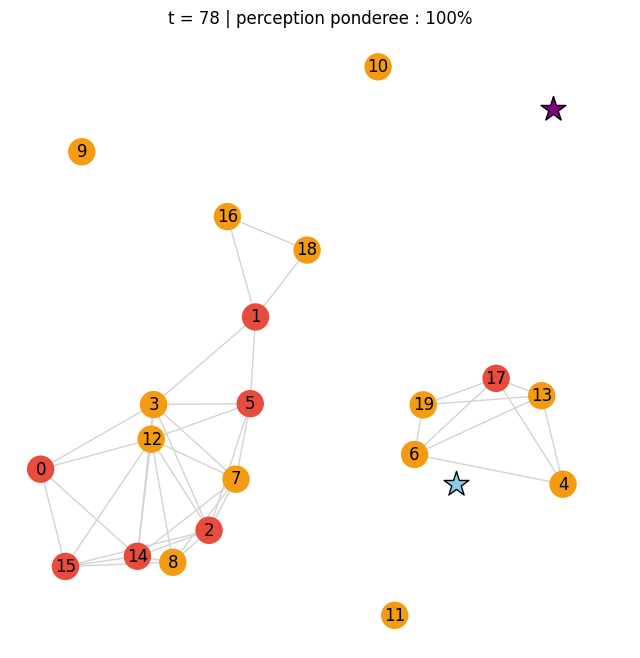

In [81]:
fig, ax = plt.subplots(figsize=(8, 8))
for t in range(0, steps, 2):
    ax.clear()
    G = snapshots[t]; pos_dict = nx.get_node_attributes(G, 'pos')
    nx.draw(G, pos=pos_dict, with_labels=True, node_color=couleur_hist[t],
            node_size=350, edge_color='lightgray', ax=ax)
    for e in events:
        if e.actif(t):
            ax.scatter(e.pos[0], e.pos[1], marker='*', s=350,
                       color=e.couleur, edgecolors='black', zorder=5)
    ax.set_xlim(-10, tailleMap + 10); ax.set_ylim(-10, tailleMap + 10)
    ax.set_title(f"t = {t} | perception ponderee : {perception_hist[t]:.0f}%")
    display.display(fig); display.clear_output(wait=True)
    time.sleep(0.1)
display.display(fig); plt.close(fig)

### Perception simple vs ponderee, et le suivi de l'accident

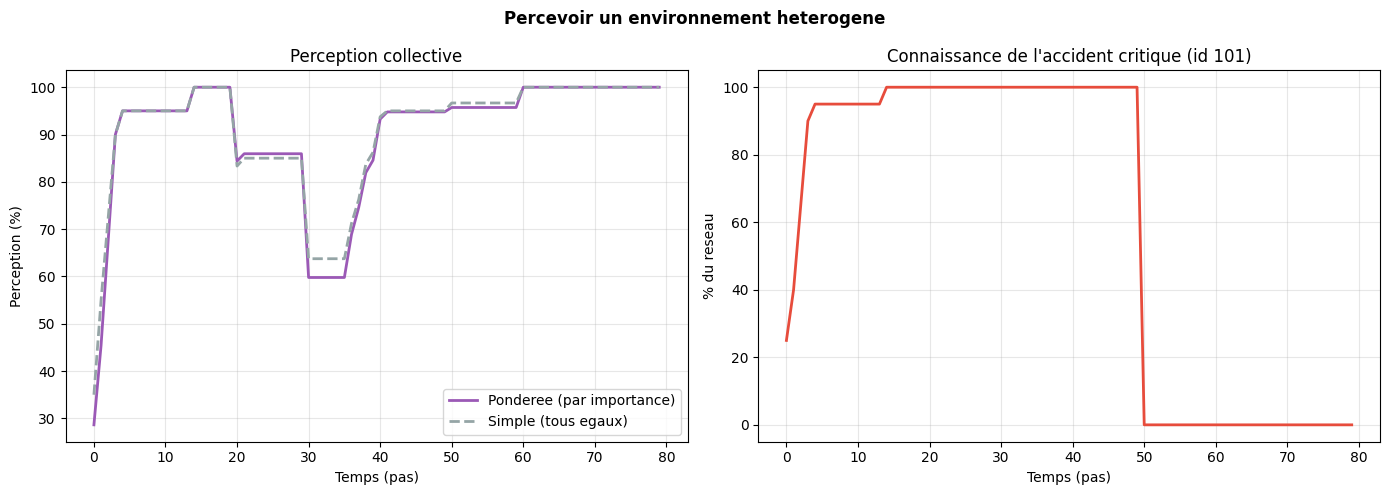

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(perception_hist, label='Ponderee (par importance)', color='#9b59b6', linewidth=2)
axes[0].plot(simple_hist, label='Simple (tous egaux)', color='#95a5a6', linewidth=2, linestyle='--')
axes[0].set_xlabel('Temps (pas)'); axes[0].set_ylabel('Perception (%)')
axes[0].set_title('Perception collective'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(accident_hist, color='#e74c3c', linewidth=2)
axes[1].set_xlabel('Temps (pas)'); axes[1].set_ylabel('% du reseau')
axes[1].set_title("Connaissance de l'accident critique (id 101)"); axes[1].grid(alpha=0.3)

plt.suptitle('Percevoir un environnement heterogene', fontweight='bold')
plt.tight_layout(); plt.show()

## 4. Questions critiques

**Q1.** Compare les deux courbes de perception (simple et ponderee). Pourquoi different-elles ?

**Q2.** Regarder la courbe de l'accident : pourquoi finit-elle par retomber a 0 ?

**Q3.** Pourquoi est-il plus juste de ponderer la perception par l'importance plutot que de compter simplement les vehicules informes ?

# Partie B — Contraintes, valeur de l'information et diffusion sélective

*Transition.* En Partie A, les véhicules partageaient **tout** ce qu'ils percevaient, sans limite. C'est irréaliste : une radio ne peut ni tout émettre, ni tout décoder. **Sous contrainte, il faut choisir quoi transmettre.** On compare trois stratégies — flooding, gossip et une diffusion **sélective** fondée sur la valeur de l'information — sur trois régimes de difficulté croissante.

On réutilise toute la brique de la Partie A (classe `Event`, perception pondérée). **Nouveauté de structure :** la mémoire d'un véhicule stocke désormais, pour chaque événement connu, son **instant de naissance**, ce qui permet de calculer son **âge** (et donc sa fraîcheur).

In [63]:
# --- On reutilise l'outillage de la Partie A (deja defini ci-dessus) ---
# graphe_proximite, generer_snapshots, la classe Event et la perception ponderee
# sont disponibles. On ajoute seulement l'identifiant de l'accident critique,
# fil rouge des scenarios qui suivent.
ACCIDENT_ID = 101

## 1. Les contraintes physiques

Deux budgets, **identiques pour les trois protocoles** (c'est la meme radio pour tout le monde) :

- **`MAX_TX`** : nombre maximal d'evenements qu'un vehicule peut **emettre** par pas de temps (temps d'antenne limite).
- **`MAX_RX`** : nombre maximal de paquets qu'un vehicule peut **decoder** par pas de temps. Decoder coute, que le paquet soit utile ou non.

La seule chose qui distingue les protocoles, c'est **quoi** emettre et **quoi** garder a la reception.

## 2. La valeur de l'information (VoI)

Toutes les informations ne se valent pas. On resume la valeur d'une information par un score
qui combine :
- son **importance** (un accident vaut plus que la meteo) ;
- sa **fraicheur** : plus une information est vieille (grand age, ou AoI, *Age of Information*),
  moins elle vaut.

$$VoI = importance \times \frac{1}{1 + age}$$

Ainsi, a age nul le score vaut l'importance, puis il decroit quand l'information vieillit.

In [82]:
def voi(importance, age):
    """Calcule la valeur de l'information (formule donnee ci-dessus).

    Parametres :
        importance : importance de l'evenement (entre 0 et 1).
        age        : age de l'information (en pas de temps depuis sa naissance).
    Retourne : le score VoI (nombre positif, au plus egal a l'importance).
    """
    score = importance * (1.0 / (1.0 + age))
    return score

# test : a age=0 le score vaut l'importance ; il decroit quand l'information vieillit
for age in [0, 1, 5, 20]:
    print(f"importance=0.9, age={age:2d} -> VoI = {voi(0.9, age):.3f}")

importance=0.9, age= 0 -> VoI = 0.900
importance=0.9, age= 1 -> VoI = 0.450
importance=0.9, age= 5 -> VoI = 0.150
importance=0.9, age=20 -> VoI = 0.043


## 3. Trois facons de choisir quoi transmettre

A chaque pas, la communication se fait en **deux passes** (pour que l'information avance d'un saut
par pas, comme en Partie 1) :

1. **Emission** : chaque vehicule choisit au plus `MAX_TX` evenements a mettre sur l'air.
2. **Reception** : tout ce qui arrive occupe la radio du destinataire, qui ne peut en decoder que `MAX_RX`.

| Protocole | Emission | Destinataires | Reception |
|---|---|---|---|
| **flooding** | au hasard | tous les voisins | decode au hasard (radio « bete ») |
| **gossip** | au hasard | un voisin tire au sort | decode au hasard |
| **VoI selectif** | les plus precieux | tous les voisins, sauf ce qu'ils savent deja | garde les plus precieux (lit un en-tete de priorite) |

Le moteur ci-dessous est fourni : lire les commentaires, c'est l'application directe des regles du tableau.

In [83]:
def perception_ponderee(mem, events, t, N):
    """Perception collective ponderee par l'importance (definie en Partie 2).

    Parametres :
        mem    : dictionnaire {vehicule: {event_id: naissance}} (memoire de chaque vehicule).
        events : liste des objets Event.
        t      : pas de temps courant.
        N      : nombre de vehicules.
    Retourne : un pourcentage entre 0 et 100.
    """
    actifs = [e for e in events if e.actif(t)]
    if not actifs: return 100.0
    total = sum(e.importance * sum(1 for i in range(N) if e.id in mem[i]) / N for e in actifs)
    return total / sum(e.importance for e in actifs) * 100

def couverture_evenement(mem, eid, events, t, N):
    """Pourcentage du reseau qui connait un evenement precis (0 s'il est inactif).

    Parametres :
        mem    : dictionnaire {vehicule: {event_id: naissance}}.
        eid    : identifiant de l'evenement suivi.
        events : liste des objets Event.
        t      : pas de temps courant.
        N      : nombre de vehicules.
    Retourne : un pourcentage entre 0 et 100.
    """
    e = next(x for x in events if x.id == eid)
    if not e.actif(t): return 0.0
    return sum(1 for i in range(N) if eid in mem[i]) / N * 100

def simuler(protocole, cfg, events, snapshots):
    """Simule sensing + communication sous contraintes pour un protocole donne.

    Parametres :
        protocole : 'flooding', 'gossip' ou 'voi'.
        cfg       : dictionnaire de configuration du scenario, contenant
                    N (nb de vehicules), steps (nb de pas), R_sense (rayon capteur),
                    MAX_TX (budget d'emission), MAX_RX (budget de decodage).
        events    : liste des objets Event.
        snapshots : liste de graphes networkx (un par pas de temps).
    Retourne : dictionnaire avec
        'cov'      : perception ponderee (%) a chaque pas ;
        'tx'       : messages emis (airtime) a chaque pas ;
        'crit'     : % du reseau connaissant l'accident critique a chaque pas ;
        'drop'     : paquets jetes faute de budget RX a chaque pas ;
        'couleurs' : couleurs des noeuds pour l'animation.
    """
    N, steps = cfg['N'], cfg['steps']
    R_sense, MAX_TX, MAX_RX = cfg['R_sense'], cfg['MAX_TX'], cfg['MAX_RX']
    ebyid = {e.id: e for e in events}

    mem = {i: {} for i in range(N)}                   # {vehicule: {event_id: naissance}}
    cov, tx, crit, drop, couleur_hist = [], [], [], [], []

    for t, G in enumerate(snapshots):
        actifs = {e.id for e in events if e.actif(t)}

        # (a) purge des evenements expires (TTL)
        for i in range(N):
            mem[i] = {eid: b for eid, b in mem[i].items() if eid in actifs}

        # (b) sensing local (rayon R_sense)
        direct = set()
        for i in range(N):
            pi = G.nodes[i]['pos']
            for e in events:
                if e.actif(t) and np.linalg.norm(pi - e.pos) <= R_sense:
                    mem[i][e.id] = e.naissance
                    direct.add(i)

        # (c) communication en deux passes
        new_mem = {i: dict(mem[i]) for i in range(N)}
        tx_count, dropped = 0, 0

        # --- passe 1 : emission (bornee par MAX_TX) ---
        outbox = {}
        for i in range(N):
            connus = [{'id': eid, 'naissance': b, 'voi': voi(ebyid[eid].importance, t - b)}
                      for eid, b in mem[i].items()]
            if protocole == 'voi':
                outbox[i] = sorted(connus, key=lambda x: x['voi'], reverse=True)[:MAX_TX]
            else:                                     # flooding / gossip : choix sans priorite
                np.random.shuffle(connus); outbox[i] = connus[:MAX_TX]

        # --- passe 2 : reception (bornee par MAX_RX) ---
        inbox = {j: [] for j in range(N)}
        for i in range(N):
            if not outbox[i]: continue
            voisins = list(G.neighbors(i))
            if not voisins: continue
            cibles = [np.random.choice(voisins)] if protocole == 'gossip' else voisins
            for j in cibles:
                for msg in outbox[i]:
                    if protocole == 'voi' and msg['id'] in mem[j]:
                        continue                       # VoI : n'emet pas ce que j sait deja
                    tx_count += 1                      # temps d'antenne consomme
                    inbox[j].append(msg)               # le paquet arrive et occupe la radio de j

        for j in range(N):
            paquets = inbox[j]
            if not paquets: continue
            if protocole == 'voi':
                nouv = {}                              # lit l'en-tete : jette doublons, garde le meilleur
                for msg in paquets:
                    if msg['id'] in mem[j]: continue
                    if msg['id'] not in nouv or msg['voi'] > nouv[msg['id']]['voi']:
                        nouv[msg['id']] = msg
                gardes = sorted(nouv.values(), key=lambda x: x['voi'], reverse=True)[:MAX_RX]
            else:                                      # radio "bete" : decode au hasard
                np.random.shuffle(paquets)
                decodes = paquets[:MAX_RX]
                dropped += max(0, len(paquets) - MAX_RX)
                gardes = [msg for msg in decodes if msg['id'] not in mem[j]]
            for msg in gardes:
                new_mem[j][msg['id']] = msg['naissance']

        mem = new_mem
        tx.append(tx_count); drop.append(dropped)
        cov.append(perception_ponderee(mem, events, t, N))
        crit.append(couverture_evenement(mem, ACCIDENT_ID, events, t, N))
        couleurs = []
        for i in range(N):
            if i in direct:   couleurs.append('#e74c3c')
            elif mem[i]:      couleurs.append('#f39c12')
            else:             couleurs.append('#3498db')
        couleur_hist.append(couleurs)

    return {'cov': cov, 'tx': tx, 'crit': crit, 'drop': drop, 'couleurs': couleur_hist}

## 4. Les trois scenarios

Le generateur cree un melange realiste d'evenements (un accident critique fixe et des evenements
mineurs aleatoires). Trois reglages servent l'experience :

| Scenario | Idee | Ce qu'on s'attend a voir |
|---|---|---|
| `facile` | peu d'evenements, budgets larges | les trois reussissent ; seul le cout differe |
| `dense` | reseau dense, plus d'evenements | la redondance du flooding explose |
| `sature` | detection locale, budgets serres | les radios saturent ; le flooding se noie |

In [84]:
CATEGORIES = [('accident', 0.9, 'red', 70), ('obstacle', 0.7, 'purple', 55),
              ('ralentissement', 0.5, 'orange', 45), ('meteo', 0.2, 'skyblue', 90)]

def make_events(n, steps, tailleMap):
    """Genere une liste d'evenements : un accident critique fixe + (n-1) evenements aleatoires.

    Parametres :
        n         : nombre total d'evenements a generer.
        steps     : nombre de pas de temps de la simulation (pour repartir les naissances).
        tailleMap : taille du cote de la carte (pour repartir les positions).
    Retourne : liste d'objets Event.
    """
    rng = np.random.default_rng()
    evs = [Event(ACCIDENT_ID, 60, 240, 0.9, 0, 80, 'red')]   # accident critique fixe
    poids = np.array([1, 2, 3, 4], dtype=float); poids /= poids.sum()  # plus d'evenements mineurs
    for k in range(n - 1):
        lab, imp, col, ttl0 = CATEGORIES[rng.choice(4, p=poids)]
        x, y = rng.random(2) * tailleMap
        naissance = int(rng.integers(0, max(1, steps - 30)))
        ttl = max(20, int(ttl0 + rng.integers(-15, 16)))
        evs.append(Event(200 + k, x, y, imp, naissance, ttl, col))
    return evs

SCENARIOS = {
 'facile': dict(N=20, R=90,  R_sense=75, MAX_TX=2, MAX_RX=3, n_events=6,  vmax=7, steps=100),
 'dense':  dict(N=25, R=140, R_sense=65, MAX_TX=2, MAX_RX=3, n_events=14, vmax=8, steps=100),
 'sature': dict(N=30, R=180, R_sense=50, MAX_TX=2, MAX_RX=2, n_events=20, vmax=9, steps=100),
}

def construire(cfg):
    """Construit le materiel d'un scenario : ses evenements et ses snapshots.

    Parametres :
        cfg : dictionnaire de configuration (une entree de SCENARIOS).
    Retourne : (events, snapshots).
    """
    events = make_events(cfg['n_events'], cfg['steps'], tailleMap)
    snapshots = generer_snapshots(cfg['N'], cfg['R'], cfg['steps'], cfg['vmax'], tailleMap)
    return events, snapshots

### Lancer un scenario

Changer `CHOIX` ci-dessous (`'facile'`, `'dense'`, `'sature'`) et reexecuter cette cellule
et les suivantes pour explorer chaque regime.

In [86]:
CHOIX = 'sature'                         # a faire varier
cfg = SCENARIOS[CHOIX]
events, snapshots = construire(cfg)
protocols = ['flooding', 'gossip', 'voi']
resultats = {p: simuler(p, cfg, events, snapshots) for p in protocols}
print(f"Scenario {CHOIX.upper()} : {cfg['n_events']} evenements | MAX_TX={cfg['MAX_TX']} MAX_RX={cfg['MAX_RX']}")

Scenario SATURE : 20 evenements | MAX_TX=2 MAX_RX=2


### Animation des trois protocoles (etoiles = evenements)

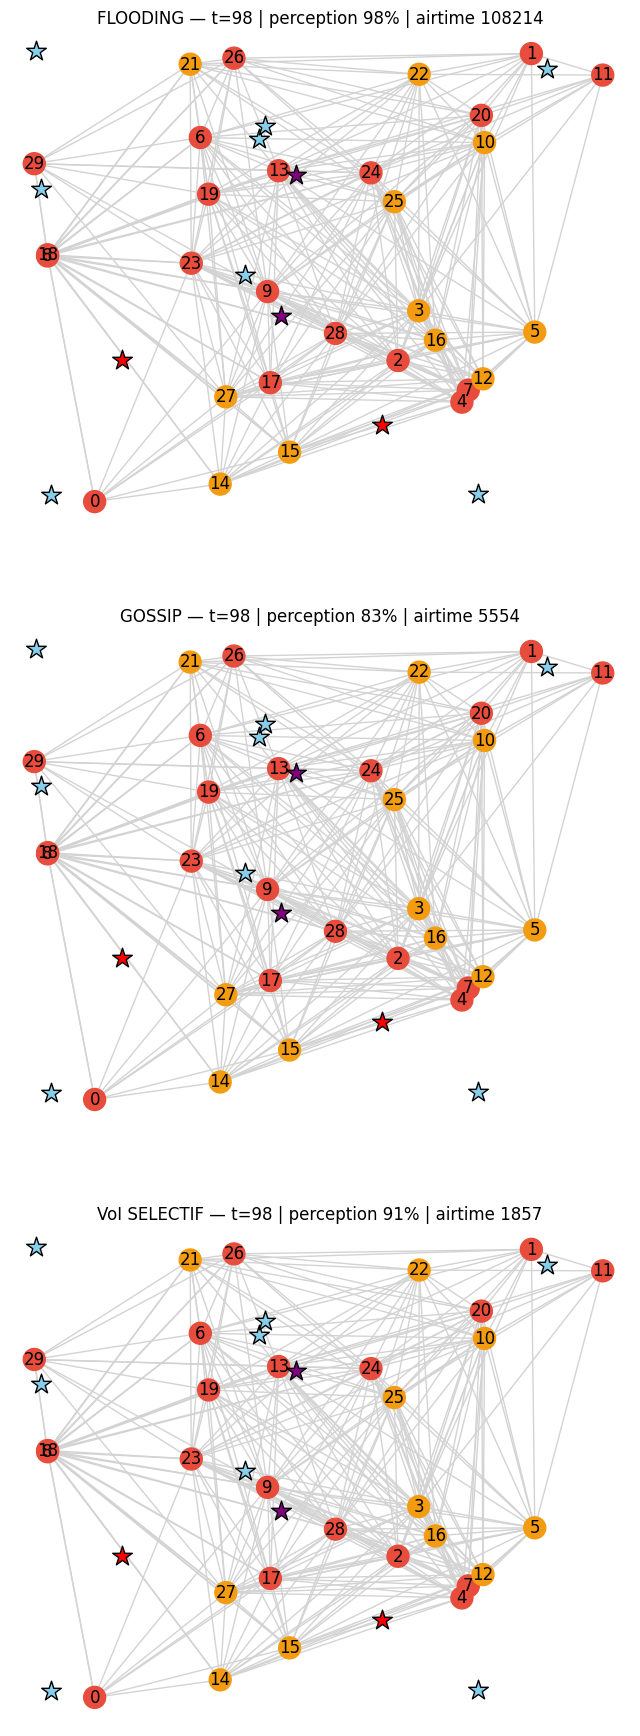

In [87]:
titres = {'flooding': 'FLOODING', 'gossip': 'GOSSIP', 'voi': 'VoI SELECTIF'}
fig, axes = plt.subplots(3, 1, figsize=(8, 22))
for t in range(0, cfg['steps'], 2):
    G = snapshots[t]; pos_dict = nx.get_node_attributes(G, 'pos')
    for ax, p in zip(axes, protocols):
        ax.clear()
        nx.draw(G, pos=pos_dict, with_labels=True, node_color=resultats[p]['couleurs'][t],
                node_size=250, edge_color='lightgray', ax=ax)
        for e in events:
            if e.actif(t):
                ax.scatter(e.pos[0], e.pos[1], marker='*', s=220,
                           color=e.couleur, edgecolors='black', zorder=5)
        ax.set_xlim(-10, tailleMap + 10); ax.set_ylim(-10, tailleMap + 10)
        ax.set_title(f"{titres[p]} — t={t} | perception {resultats[p]['cov'][t]:.0f}% | "
                     f"airtime {sum(resultats[p]['tx'][:t+1])}")
    display.display(fig); display.clear_output(wait=True)
    time.sleep(0.1)
display.display(fig); plt.close(fig)

### Bilan : les compromis

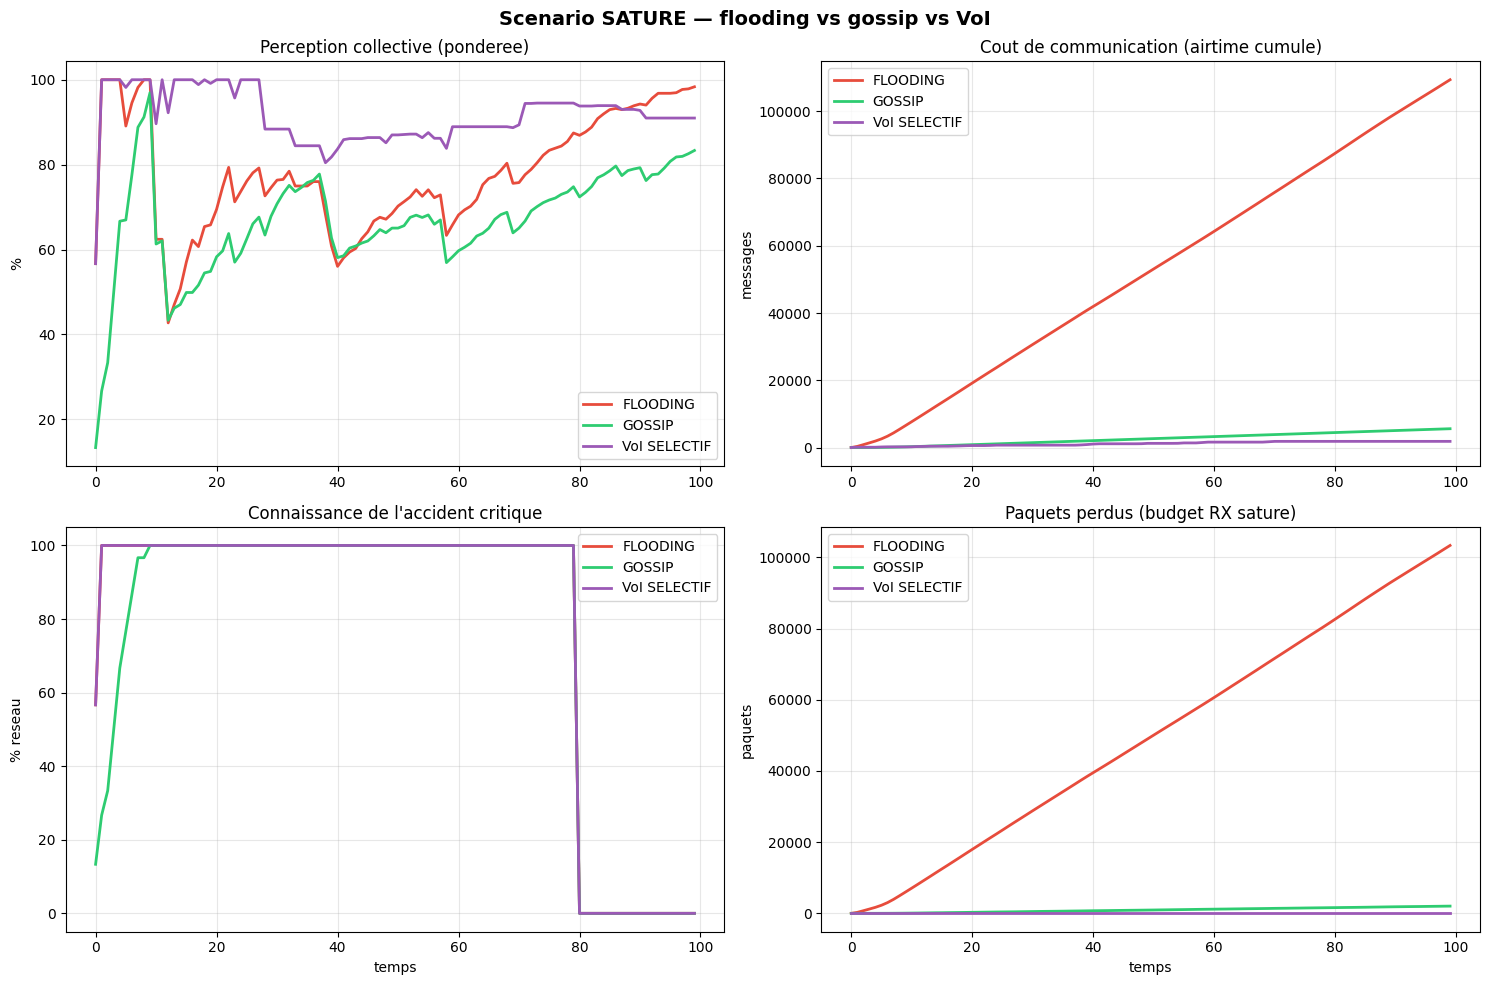


--- Bilan SATURE ---
FLOODING     : perception  98.3% | airtime 109338 | perdus RX 103372 | efficacite   0.09
GOSSIP       : perception  83.3% | airtime   5614 | perdus RX   2029 | efficacite   1.48
VoI SELECTIF : perception  91.0% | airtime   1857 | perdus RX      0 | efficacite   4.90


In [88]:
couleurs = {'flooding': '#e74c3c', 'gossip': '#2ecc71', 'voi': '#9b59b6'}
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for p in protocols:
    axes[0,0].plot(resultats[p]['cov'], label=titres[p], color=couleurs[p], linewidth=2)
axes[0,0].set_title('Perception collective (ponderee)'); axes[0,0].set_ylabel('%')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

for p in protocols:
    axes[0,1].plot(np.cumsum(resultats[p]['tx']), label=titres[p], color=couleurs[p], linewidth=2)
axes[0,1].set_title('Cout de communication (airtime cumule)'); axes[0,1].set_ylabel('messages')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

for p in protocols:
    axes[1,0].plot(resultats[p]['crit'], label=titres[p], color=couleurs[p], linewidth=2)
axes[1,0].set_title("Connaissance de l'accident critique"); axes[1,0].set_xlabel('temps'); axes[1,0].set_ylabel('% reseau')
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

for p in protocols:
    axes[1,1].plot(np.cumsum(resultats[p]['drop']), label=titres[p], color=couleurs[p], linewidth=2)
axes[1,1].set_title('Paquets perdus (budget RX sature)'); axes[1,1].set_xlabel('temps'); axes[1,1].set_ylabel('paquets')
axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

plt.suptitle(f'Scenario {CHOIX.upper()} — flooding vs gossip vs VoI', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"\n--- Bilan {CHOIX.upper()} ---")
for p in protocols:
    c = sum(resultats[p]['tx']); per = resultats[p]['cov'][-1]; d = sum(resultats[p]['drop'])
    print(f"{titres[p]:13s}: perception {per:5.1f}% | airtime {c:6d} | perdus RX {d:6d} | "
          f"efficacite {per/max(c,1)*100:6.2f}")

## 5. Questions critiques

Pour repondre, executer le notebook dans les trois scenarios (`facile`, `dense`, `sature`)
et comparer les bilans. Les resultats etant aleatoires, les valeurs exactes changent d'une
execution a l'autre : ce sont les ordres de grandeur et les tendances qui comptent.

**Q1.** Dans `facile`, le VoI est-il meilleur que le flooding sur la perception ? Et sur le cout ?

**Reponse attendue.** Sur la perception, non : les deux peuvent generalement atteindre des niveaux
comparables, proches de 100 %. Sur le cout, oui, tres nettement : le VoI depense un airtime tres faible
la ou le flooding en depense des milliers. Sans contrainte serree, la selection n'apporte pas une meilleure
perception : elle apporte une perception equivalente pour un cout beaucoup plus faible.

**Q2.** Dans `sature`, le flooding est celui qui depense le plus d'airtime. Est-il pour autant celui qui percoit le mieux ? Regarder aussi sa courbe de paquets perdus.

**Reponse attendue.** Pas forcement, et c'est contre-intuitif. En saturant le canal, le flooding noie les
recepteurs : ils recoivent bien plus de paquets que leur budget `MAX_RX`, donc en jettent beaucoup, au hasard,
ce qui peut faire perdre l'information importante. Resultat typique : il depense des dizaines de fois plus que
le VoI pour une perception comparable. Emettre plus ne garantit pas percevoir mieux : au-dela d'un certain
point, le volume devient nuisible.

**Q3.** Le VoI est-il toujours meilleur ? Formuler la conclusion generale : quand la diffusion selective est-elle simplement plus economique, et quand devient-elle indispensable ?

**Reponse attendue.** Le VoI n'est pas meilleur dans l'absolu : son avantage depend du regime.
- Reseau peu contraint (`facile`) : il ne fait qu'economiser des ressources (perception equivalente, cout bien moindre).
- Reseau congestionne (`sature`) : il devient indispensable, car c'est le seul qui protege l'information
importante quand le canal et les radios sont satures.

Conclusion generale : plus les contraintes se durcissent, plus le choix intelligent de quoi transmettre
devient critique.

**Q4 (ouverture).** Le VoI suppose qu'un vehicule sait deja ce que ses voisins connaissent, et qu'un en-tete de priorite est lisible sans cout. Ces hypotheses sont-elles realistes ?

**Reponse attendue.** Pas completement. En realite, savoir ce que connait un voisin demande d'echanger
des messages supplementaires, qui ont eux-memes un cout (ignore ici). De meme, lire une priorite suppose un
en-tete fiable. Ce sont des simplifications du modele : si elles tombent, l'avantage du VoI diminue. Autre
limite : une information jugee peu importante maintenant peut devenir critique plus tard, et un VoI trop
agressif risque de l'avoir ignoree. Cela motive une decision plus adaptative (Partie 4).

---
## Conclusion du TP2

**Partie A — percevoir**
- Un véhicule ISAC **perçoit** (capteur, rayon `R_sense`) *et* communique.
- Les événements ont une **importance** et une **durée de validité (TTL)** : tout n'a ni la même valeur ni la même durée.
- La **perception collective pondérée** mesure la qualité de la perception en privilégiant ce qui compte.

**Partie B — choisir sous contraintes**
- Sous budgets (`MAX_TX`, `MAX_RX`), on ne peut pas tout transmettre : il faut **choisir**.
- La **valeur de l'information (VoI)** = importance × fraîcheur guide ce choix.
- Le bon protocole **dépend du régime** : la sélection *économise* quand le réseau est peu contraint, et devient *indispensable* sous congestion.
- Tout modèle repose sur des **hypothèses** qu'il faut savoir expliciter et critiquer.

**Ouverture.** Et si chaque véhicule **apprenait** seul à régler sa stratégie de transmission ? C'est la piste de l'intelligence distribuée (Partie 4).